# INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 02 (WEEK 1)
## Ứng dụng 3: Khám phá Sở thích Ngành hàng E-Commerce (Category & Interest Discovery)
**Tập dữ liệu:** `Womens Clothing E-Commerce Reviews.csv`  
**Đầu vào (Input):** Văn bản bình luận (`Title` + `Review Text`) mã hóa qua TF-IDF  
**Mục tiêu (Target):** Danh mục sản phẩm chi tiết (`Class Name`: *Dresses, Knits, Blouses, Sweaters, Pants, Jeans, Skirts, Jackets...*)  
**Mô hình huấn luyện & so sánh:** 6 mô hình ML (Logistic Regression, Linear SVM, Multinomial Naive Bayes, Decision Tree, Random Forest, SGD Classifier).

---
### 1. Khởi tạo Môi trường & Nạp Dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# 6 Mô hình ML phân loại đa lớp
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Thiết lập hiển thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Tải dữ liệu
df_raw = pd.read_csv('data/Womens Clothing E-Commerce Reviews.csv')
print(f"✅ Tải dữ liệu thành công: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột")

✅ Tải dữ liệu thành công: 23,486 dòng, 11 cột


---
### 2. Tiền xử lý Dữ liệu & Lọc Danh mục Phổ biến (Data Filtering & Preparation)

Để bài toán phân loại đa lớp đạt độ tin cậy và cân bằng mẫu tốt, ta:
1. Loại bỏ các dòng có `Review Text` hoặc `Class Name` bị trống.
2. Lọc ra **Top 8 Danh mục sản phẩm phổ biến nhất** (chiếm > 92% dữ liệu): *Dresses, Knits, Blouses, Sweaters, Pants, Jeans, Skirts, Jackets*.
3. Kết hợp `Title` và `Review Text` thành trường văn bản đầy đủ `Full_Text` và làm sạch (chuyển chữ thường, xóa ký tự đặc biệt).

In [2]:
# 1. Lọc dữ liệu sạch
df = df_raw.dropna(subset=['Review Text', 'Class Name']).copy()

# 2. Chọn Top 8 Class Name phổ biến nhất
top_classes = df['Class Name'].value_counts().head(8).index.tolist()
df = df[df['Class Name'].isin(top_classes)].copy()

# 3. Tạo văn bản kết hợp Full_Text
df['Clean_Title'] = df['Title'].fillna('')
df['Full_Text'] = df['Clean_Title'] + ' ' + df['Review Text']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Clean_Text'] = df['Full_Text'].apply(clean_text)

# 4. Mã hóa nhãn Target (Class Name)
label_encoder = LabelEncoder()
df['Target_Label'] = label_encoder.fit_transform(df['Class Name'])

print(f"Số lượng mẫu sau khi lọc Top 8 Danh mục: {len(df):,} mẫu")
print("\nPhân bố số lượng mẫu theo từng Danh mục (Class Name):")
class_dist = df['Class Name'].value_counts()
for name, cnt in class_dist.items():
    print(f"  • {name:15s}: {cnt:5,} mẫu ({cnt/len(df)*100:.1f}%)")

Số lượng mẫu sau khi lọc Top 8 Danh mục: 19,550 mẫu

Phân bố số lượng mẫu theo từng Danh mục (Class Name):
  • Dresses        : 6,145 mẫu (31.4%)
  • Knits          : 4,626 mẫu (23.7%)
  • Blouses        : 2,983 mẫu (15.3%)
  • Sweaters       : 1,380 mẫu (7.1%)
  • Pants          : 1,350 mẫu (6.9%)
  • Jeans          : 1,104 mẫu (5.6%)
  • Fine gauge     : 1,059 mẫu (5.4%)
  • Skirts         :   903 mẫu (4.6%)


---
### 3. Phân chia Train/Test & Biểu diễn Đặc trưng TF-IDF (Representation)

Theo Lecture 02:
* Phân chia tập dữ liệu theo tỷ lệ **80% Training - 20% Testing** (Stratified theo `Class Name` để đảm bảo đồng đều tỷ lệ các lớp).
* Áp dụng `TfidfVectorizer` với:
  * `max_features = 3000` (giữ lại 3,000 từ khóa mang tính phân biệt cao nhất).
  * `ngram_range = (1, 2)` (trích xuất cả từ đơn Unigram và cụm 2 từ Bigram).
  * `sublinear_tf = True` (áp dụng thang đo log cho TF: $1 + \ln(\text{TF})$).

In [3]:
# 1. Phân chia Train / Test
X_text = df['Clean_Text'].values
y = df['Target_Label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Huấn luyện bộ trích xuất TF-IDF trên tập Train (Tránh Data Leakage)
tfidf_vec = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    norm='l2'
)

X_train = tfidf_vec.fit_transform(X_train_raw)
X_test = tfidf_vec.transform(X_test_raw)

print(f"✅ Ma trận đặc trưng Tập huấn luyện (X_train): {X_train.shape[0]:,} mẫu x {X_train.shape[1]:,} đặc trưng")
print(f"✅ Ma trận đặc trưng Tập kiểm thử    (X_test) : {X_test.shape[0]:,} mẫu x {X_test.shape[1]:,} đặc trưng")

✅ Ma trận đặc trưng Tập huấn luyện (X_train): 15,640 mẫu x 3,000 đặc trưng
✅ Ma trận đặc trưng Tập kiểm thử    (X_test) : 3,910 mẫu x 3,000 đặc trưng


---
### 4. Huấn luyện & Đánh giá So sánh 6 Mô hình Máy học (Model Development)

In [4]:
# Khởi tạo cấu trúc lưu trữ mô hình và thời gian huấn luyện cho 6 mô hình
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {}
training_times = {}
print("Sẵn sàng huấn luyện 6 mô hình phân loại đa lớp độc lập...")


Sẵn sàng huấn luyện 6 mô hình phân loại đa lớp độc lập...


#### 4.1. Logistic Regression


In [5]:
start_time = time.time()
clf_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf_lr.fit(X_train, y_train)
train_time = time.time() - start_time

models["Logistic Regression"] = clf_lr
training_times["Logistic Regression"] = train_time
print(f"✅ Logistic Regression: Hoàn thành sau {train_time:.2f} giây")


✅ Logistic Regression: Hoàn thành sau 0.68 giây


#### 4.2. Linear SVM


In [6]:
start_time = time.time()
clf_svm = LinearSVC(C=1.0, random_state=42, max_iter=2000)
clf_svm.fit(X_train, y_train)
train_time = time.time() - start_time

models["Linear SVM"] = clf_svm
training_times["Linear SVM"] = train_time
print(f"✅ Linear SVM: Hoàn thành sau {train_time:.2f} giây")


✅ Linear SVM: Hoàn thành sau 0.35 giây


#### 4.3. Multinomial Naive Bayes


In [7]:
start_time = time.time()
clf_mnb = MultinomialNB(alpha=0.1)
clf_mnb.fit(X_train, y_train)
train_time = time.time() - start_time

models["Multinomial Naive Bayes"] = clf_mnb
training_times["Multinomial Naive Bayes"] = train_time
print(f"✅ Multinomial Naive Bayes: Hoàn thành sau {train_time:.2f} giây")


✅ Multinomial Naive Bayes: Hoàn thành sau 0.00 giây


#### 4.4. SGD Classifier (Log Loss)


In [8]:
start_time = time.time()
clf_sgd = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)
clf_sgd.fit(X_train, y_train)
train_time = time.time() - start_time

models["SGD Classifier (Log Loss)"] = clf_sgd
training_times["SGD Classifier (Log Loss)"] = train_time
print(f"✅ SGD Classifier (Log Loss): Hoàn thành sau {train_time:.2f} giây")


✅ SGD Classifier (Log Loss): Hoàn thành sau 0.10 giây


#### 4.5. Decision Tree


In [9]:
start_time = time.time()
clf_dt = DecisionTreeClassifier(max_depth=30, random_state=42)
clf_dt.fit(X_train, y_train)
train_time = time.time() - start_time

models["Decision Tree"] = clf_dt
training_times["Decision Tree"] = train_time
print(f"✅ Decision Tree: Hoàn thành sau {train_time:.2f} giây")


✅ Decision Tree: Hoàn thành sau 1.03 giây


#### 4.6. Random Forest


In [10]:
start_time = time.time()
clf_rf = RandomForestClassifier(n_estimators=150, max_depth=25, n_jobs=-1, random_state=42)
clf_rf.fit(X_train, y_train)
train_time = time.time() - start_time

models["Random Forest"] = clf_rf
training_times["Random Forest"] = train_time
print(f"✅ Random Forest: Hoàn thành sau {train_time:.2f} giây")


✅ Random Forest: Hoàn thành sau 0.48 giây


In [11]:
results_list = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)
    
    results_list.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Macro F1 (%)": round(f1_macro * 100, 2),
        "Weighted F1 (%)": round(f1_weighted * 100, 2),
        "Macro Precision (%)": round(prec_macro * 100, 2),
        "Macro Recall (%)": round(rec_macro * 100, 2),
        "Training Time (s)": round(training_times[name], 3)
    })

df_results = pd.DataFrame(results_list).sort_values(by="Weighted F1 (%)", ascending=False)
print("=== BẢNG SO SÁNH HIỆU NĂNG 6 MÔ HÌNH DỰ ĐOÁN SỞ THÍCH NGÀNH HÀNG (CLASS NAME) ===")
df_results


=== BẢNG SO SÁNH HIỆU NĂNG 6 MÔ HÌNH DỰ ĐOÁN SỞ THÍCH NGÀNH HÀNG (CLASS NAME) ===


,Model,Accuracy (%),Macro F1 (%),Weighted F1 (%),Macro Precision (%),Macro Recall (%),Training Time (s)
0,Logistic Regression,72.89,68.83,72.46,73.51,66.24,0.678
3,SGD Classifier (Log Loss),72.17,66.24,70.96,74.43,63.71,0.097
1,Linear SVM,70.97,66.93,70.67,68.12,66.13,0.352
4,Decision Tree,65.22,57.82,64.27,62.03,56.23,1.035
5,Random Forest,66.73,56.52,63.32,67.45,53.90,0.480
2,Multinomial Naive Bayes,64.12,53.80,60.90,68.96,49.64,0.003


---
### 5. Trực quan hóa So sánh Hiệu năng Mô hình

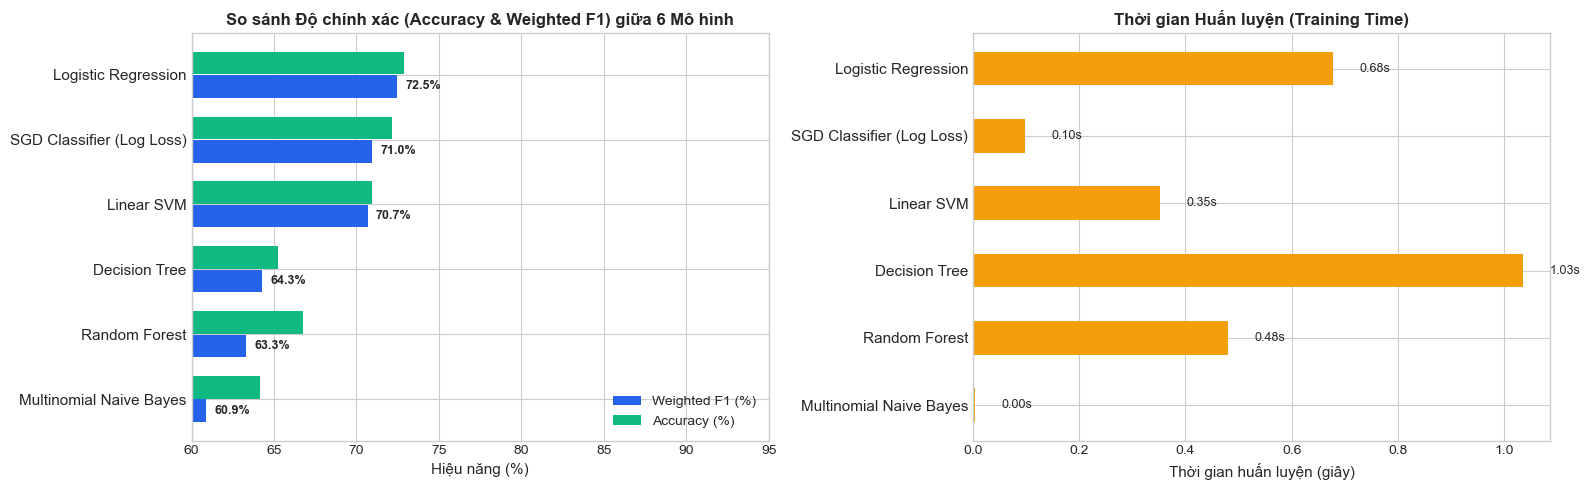

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. So sánh Weighted F1 & Accuracy
df_plot = df_results.sort_values(by='Weighted F1 (%)', ascending=True)
y_pos = np.arange(len(df_plot))

axes[0].barh(y_pos - 0.18, df_plot['Weighted F1 (%)'], height=0.35, label='Weighted F1 (%)', color='#2563eb')
axes[0].barh(y_pos + 0.18, df_plot['Accuracy (%)'], height=0.35, label='Accuracy (%)', color='#10b981')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_plot['Model'], fontsize=11)
axes[0].set_xlabel('Hiệu năng (%)', fontsize=11)
axes[0].set_title('So sánh Độ chính xác (Accuracy & Weighted F1) giữa 6 Mô hình', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim(60, 95)
for i, v in enumerate(df_plot['Weighted F1 (%)']):
    axes[0].text(v + 0.5, i - 0.18, f"{v:.1f}%", va='center', fontsize=9, fontweight='bold')

# 2. Thời gian huấn luyện
axes[1].barh(y_pos, df_plot['Training Time (s)'], color='#f59e0b', height=0.5)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(df_plot['Model'], fontsize=11)
axes[1].set_xlabel('Thời gian huấn luyện (giây)', fontsize=11)
axes[1].set_title('Thời gian Huấn luyện (Training Time)', fontsize=12, fontweight='bold')
for i, v in enumerate(df_plot['Training Time (s)']):
    axes[1].text(v + 0.05, i, f"{v:.2f}s", va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
### 6. Đánh giá Chi tiết Mô hình Tốt nhất (Linear SVM) & Confusion Matrix

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

     Blouses       0.53      0.52      0.53       596
     Dresses       0.89      0.91      0.90      1229
  Fine gauge       0.42      0.29      0.35       212
       Jeans       0.83      0.77      0.80       221
       Knits       0.60      0.66      0.63       925
       Pants       0.75      0.73      0.74       270
      Skirts       0.83      0.85      0.84       181
    Sweaters       0.60      0.56      0.58       276

    accuracy                           0.71      3910
   macro avg       0.68      0.66      0.67      3910
weighted avg       0.71      0.71      0.71      3910



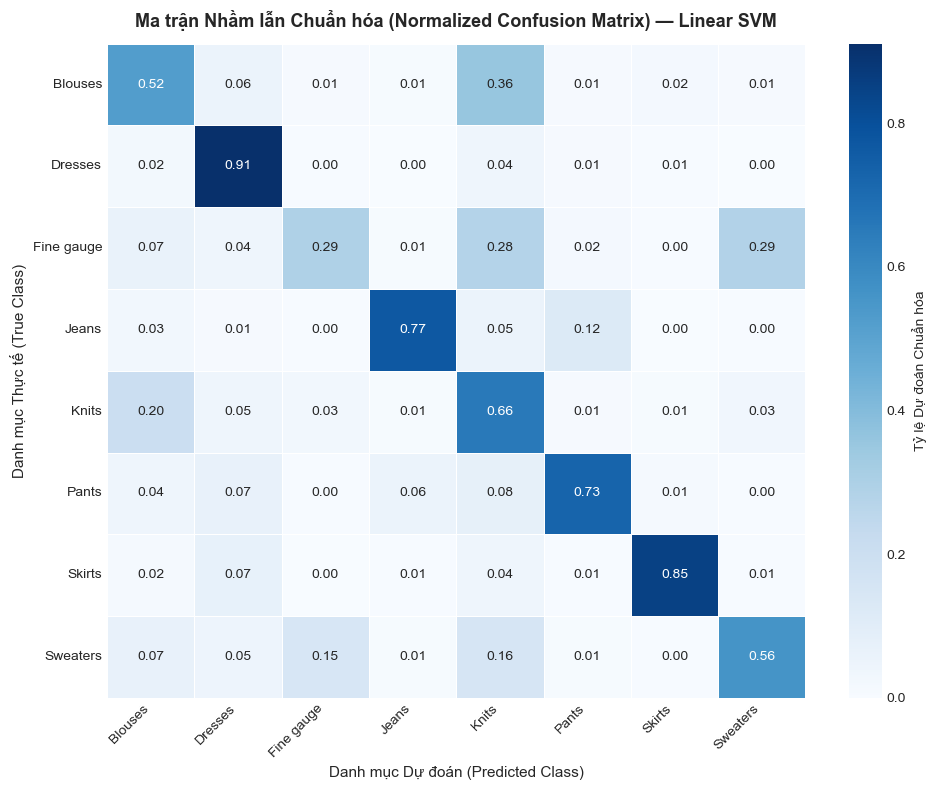

In [13]:
best_model = models["Linear SVM"]
y_pred_best = best_model.predict(X_test)
class_labels = label_encoder.classes_

print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred_best, target_names=class_labels))

# Vẽ Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    cbar_kws={'label': 'Tỷ lệ Dự đoán Chuẩn hóa'}
)
plt.title("Ma trận Nhầm lẫn Chuẩn hóa (Normalized Confusion Matrix) — Linear SVM", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Danh mục Dự đoán (Predicted Class)", fontsize=11)
plt.ylabel("Danh mục Thực tế (True Class)", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
### 7. Khám phá Từ khóa Đặc trưng Ngữ nghĩa cho Từng Ngành hàng (Keyword Extraction)

Trích xuất các từ khóa có trọng số học cao nhất (Highest Linear Coefficients) trong mô hình cho từng danh mục sản phẩm:

In [14]:
feature_names = np.array(tfidf_vec.get_feature_names_out())

print("=" * 85)
print("TOP 8 TỪ KHÓA ĐẶC TRƯNG NHẤT CHO TỪNG DANH MỤC THỜI TRANG (DISCRIMINATIVE KEYWORDS):")
print("=" * 85)

for idx, class_name in enumerate(class_labels):
    coefs = best_model.coef_[idx]
    top_indices = np.argsort(coefs)[-8:][::-1]
    top_words = feature_names[top_indices]
    top_scores = coefs[top_indices]
    
    print(f"\n🏷️ DANH MỤC: [{class_name.upper()}]")
    for w, s in zip(top_words, top_scores):
        print(f"    • {w:18s} (Hệ số trọng số: {s:+.3f})")

TOP 8 TỪ KHÓA ĐẶC TRƯNG NHẤT CHO TỪNG DANH MỤC THỜI TRANG (DISCRIMINATIVE KEYWORDS):

🏷️ DANH MỤC: [BLOUSES]
    • blouse             (Hệ số trọng số: +3.252)
    • plaid              (Hệ số trọng số: +2.876)
    • flannel            (Hệ số trọng số: +2.578)
    • crisp              (Hệ số trọng số: +2.188)
    • paris              (Hệ số trọng số: +2.072)
    • maeve              (Hệ số trọng số: +2.001)
    • dots               (Hệ số trọng số: +1.991)
    • chambray           (Hệ số trọng số: +1.892)

🏷️ DANH MỤC: [DRESSES]
    • dress              (Hệ số trọng số: +13.433)
    • dresses            (Hệ số trọng số: +4.739)
    • love dress         (Hệ số trọng số: +3.047)
    • sack               (Hệ số trọng số: +2.305)
    • bodice             (Hệ số trọng số: +2.287)
    • maxi               (Hệ số trọng số: +2.191)
    • bought dress       (Hệ số trọng số: +2.110)
    • slip               (Hệ số trọng số: +2.089)

🏷️ DANH MỤC: [FINE GAUGE]
    • sweater            (Hệ số trọng s

---
### 8. Thử nghiệm Dự đoán Trực tiếp với Câu Bình luận Mới (Inference Demo)

In [15]:
test_comments = [
    "I bought this gorgeous floral maxi for a summer wedding, length hits perfectly at my ankles!",
    "Super soft knit material, keeps me very warm and cozy during chilly winter days.",
    "The denim fits great on my waist and hips, perfect stretch skinny fit.",
    "A stylish tailored blazer that goes perfectly with formal office outfits."
]

print("=== THỬ NGHIỆM DỰ ĐOÁN SỞ THÍCH NGÀNH HÀNG TỪ BÌNH LUẬN KHÁCH HÀNG ===")
for comment in test_comments:
    vec = tfidf_vec.transform([clean_text(comment)])
    pred_idx = best_model.predict(vec)[0]
    pred_class = label_encoder.inverse_transform([pred_idx])[0]
    
    print(f"\n📝 Câu bình luận: \"{comment}\"")
    print(f"🎯 Dự đoán sở thích ngành hàng (Class Name): ➔ [{pred_class.upper()}]")

=== THỬ NGHIỆM DỰ ĐOÁN SỞ THÍCH NGÀNH HÀNG TỪ BÌNH LUẬN KHÁCH HÀNG ===

📝 Câu bình luận: "I bought this gorgeous floral maxi for a summer wedding, length hits perfectly at my ankles!"
🎯 Dự đoán sở thích ngành hàng (Class Name): ➔ [DRESSES]

📝 Câu bình luận: "Super soft knit material, keeps me very warm and cozy during chilly winter days."
🎯 Dự đoán sở thích ngành hàng (Class Name): ➔ [KNITS]

📝 Câu bình luận: "The denim fits great on my waist and hips, perfect stretch skinny fit."
🎯 Dự đoán sở thích ngành hàng (Class Name): ➔ [JEANS]

📝 Câu bình luận: "A stylish tailored blazer that goes perfectly with formal office outfits."
🎯 Dự đoán sở thích ngành hàng (Class Name): ➔ [KNITS]
